In [67]:
!pip install tensorflow pandas numpy matplotlib scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.layers import Dropout

In [68]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets (3).csv


In [69]:
df = pd.read_csv('Tweets.csv')
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [70]:
# clean column names
df.columns = df.columns.str.strip()

# keep only needed columns
df = df[['text', 'sentiment']]

# handle missing values
df['text'] = df['text'].fillna('')
df['text'] = df['text'].astype(str)

df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [71]:
# clean column names
df.columns = df.columns.str.strip()

# keep only needed columns
df = df[['text', 'sentiment']]

# handle missing values
df['text'] = df['text'].fillna('')
df['text'] = df['text'].astype(str)


# 🔥 SPLIT FIRST
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['sentiment'], test_size=0.2, random_state=42
)

# 🔥 THEN ENCODE (VERY IMPORTANT)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Train labels:", np.unique(y_train))
print("Test labels:", np.unique(y_test))

Train labels: [0 1 2 3]
Test labels: [0 1 2 3]


In [74]:
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print(X_train_pad.shape)

(21985, 100)


In [75]:
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

Number of classes: 4


In [76]:
rnn_model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(128),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.3954 - loss: 1.0971 - val_accuracy: 0.4060 - val_loss: 1.0892
Epoch 2/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.4018 - loss: 1.0906 - val_accuracy: 0.4060 - val_loss: 1.0921
Epoch 3/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.3971 - loss: 1.0913 - val_accuracy: 0.4060 - val_loss: 1.0914
Epoch 4/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.4031 - loss: 1.0896 - val_accuracy: 0.4060 - val_loss: 1.0883
Epoch 5/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.4028 - loss: 1.0903 - val_accuracy: 0.4060 - val_loss: 1.0916


In [78]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [79]:
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 136s 193ms/step - accuracy: 0.3910 - loss: 1.1014 - val_accuracy: 0.4060 - val_loss: 1.0940
Epoch 2/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 133s 193ms/step - accuracy: 0.4011 - loss: 1.0914 - val_accuracy: 0.4060 - val_loss: 1.0884
Epoch 3/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 133s 194ms/step - accuracy: 0.4042 - loss: 1.0903 - val_accuracy: 0.4060 - val_loss: 1.0902
Epoch 4/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 144s 197ms/step - accuracy: 0.4036 - loss: 1.0897 - val_accuracy: 0.4060 - val_loss: 1.0898
Epoch 5/5
688/688 ━━━━━━━━━━━━━━━━━━━━ 141s 195ms/step - accuracy: 0.4040 - loss: 1.0889 - val_accuracy: 0.4060 - val_loss: 1.0885


In [80]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_pad, y_test)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4060 - loss: 1.0916
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4060 - loss: 1.0885
RNN Accuracy: 0.40603965520858765
LSTM Accuracy: 0.40603965520858765


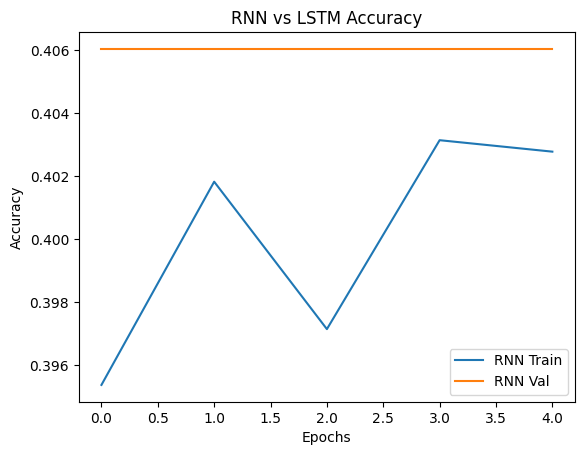

In [81]:
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('RNN vs LSTM Accuracy')
plt.show()

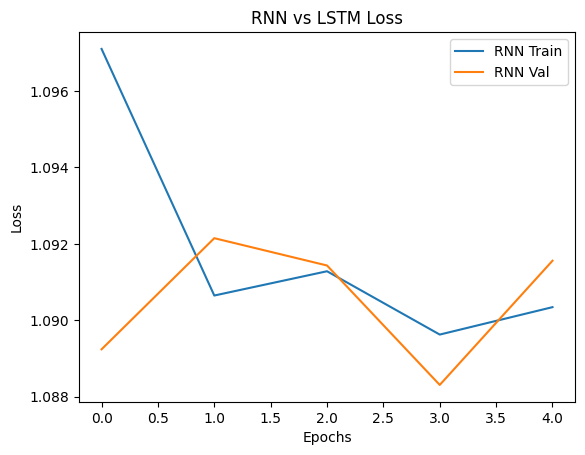

In [82]:
plt.plot(history_rnn.history['loss'], label='RNN Train')
plt.plot(history_rnn.history['val_loss'], label='RNN Val')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('RNN vs LSTM Loss')
plt.show()

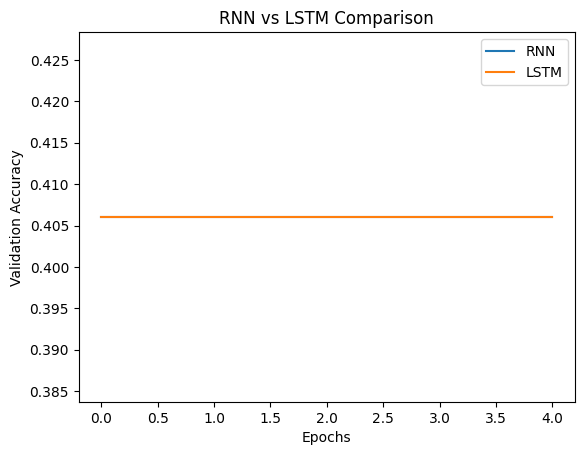

In [83]:
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('RNN vs LSTM Comparison')
plt.legend()
plt.show()

In [84]:
print("Final Comparison:\n")

print(f"RNN Accuracy: {rnn_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")

if lstm_acc > rnn_acc:
    print("👉 LSTM performs better")
else:
    print("👉 RNN performs better")

Final Comparison:

RNN Accuracy: 0.4060
LSTM Accuracy: 0.4060
👉 RNN performs better
